# 04 - XGBoost

Primary advanced gradient boosted model - typically the strongest raw predictive performance on tabular data, with built in regularization.


## Setup

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
from xgboost import XGBClassifier
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']


## 1. Train (default parameters - tuning happens in Stage 8)

In [2]:
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_val)
y_score = xgb.predict_proba(X_val)[:, 1]


## 2. Evaluate on the validation set

In [3]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
import json
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(y_true, y_pred, y_score, model_name, save_prefix=None):
    metrics = {
        'model': model_name,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    print(f"--- {model_name} (validation set) ---")
    for k, v in metrics.items():
        if k != 'model':
            print(f"  {k}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['On time (0)', 'Late (1)']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}", color='#4C72B0', linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, label=f"PR-AUC = {metrics['pr_auc']:.3f}", color='#C44E52', linewidth=2)
    axes[2].set_title(f'{model_name} — Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc='lower left')

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'../../../reports/figures/{save_prefix}_evaluation.png', dpi=120, bbox_inches='tight')
    plt.show()

    return metrics

def save_metrics(metrics, path):
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"Saved metrics to {path}")


--- XGBoost (validation set) ---
  recall: 0.6062
  precision: 0.8160
  f1: 0.6956
  roc_auc: 0.7595
  pr_auc: 0.8250

              precision    recall  f1-score   support

 On time (0)       0.64      0.84      0.73      3611
    Late (1)       0.82      0.61      0.70      4279

    accuracy                           0.71      7890
   macro avg       0.73      0.72      0.71      7890
weighted avg       0.74      0.71      0.71      7890



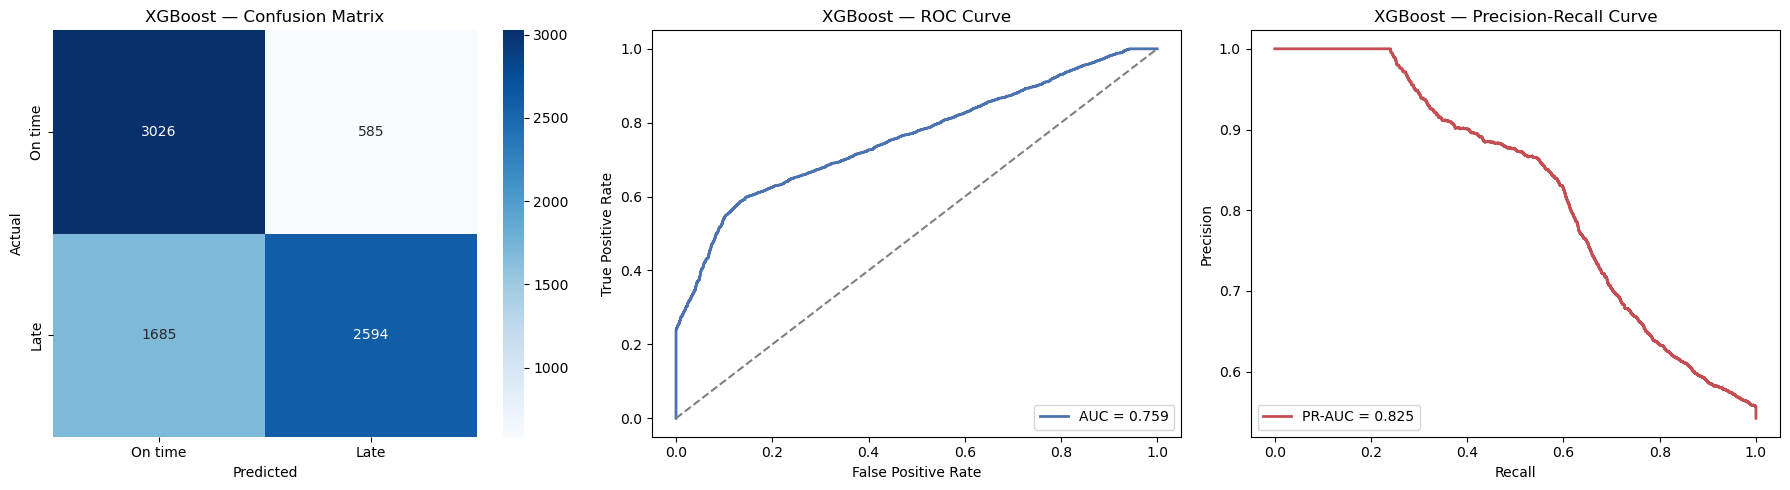

In [4]:
xgb_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'XGBoost', save_prefix='xgboost')


**What we found:**

**XGBoost doesn't clearly beat Random Forest, they're near identical performers with different tradeoffs, which is itself the finding worth reporting:**

| Metric | Baseline | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|---|
| Recall | 0.5349 | 0.5543 | **0.6172** | 0.6062 |
| Precision | 0.8391 | 0.8379 | 0.7924 | **0.8160** |
| F1 | 0.6533 | 0.6672 | 0.6939 | **0.6956** |
| ROC-AUC | 0.7270 | 0.7394 | 0.7580 | **0.7595** |
| PR-AUC | 0.7429 | 0.8105 | 0.8234 | **0.8250** |

F1, ROC-AUC, and PR-AUC are essentially tied between Random Forest and XGBoost (differences under 0.002), but the two models trade Recall for Precision in opposite directions: **Random Forest has the higher Recall (0.6172 vs. 0.6062), while XGBoost has the higher Precision (0.8160 vs. 0.7924).**

Since Recall is our stated primary metric, **Random Forest is currently the stronger candidate on the metric that matters most for this business problem**, by about one percentage point, even though XGBoost is often assumed to be the stronger algorithm by default. This is a genuinely useful, honest finding, not a disappointing one: it means the choice between them shouldn't be made on reputation, it should go into Stage 8's Optuna tuning for both, and the final pick should come from tuned performance and threshold optimization, not a default parameters snapshot. Worth carrying both forward as candidates rather than eliminating one prematurely.


## 3. Feature importances

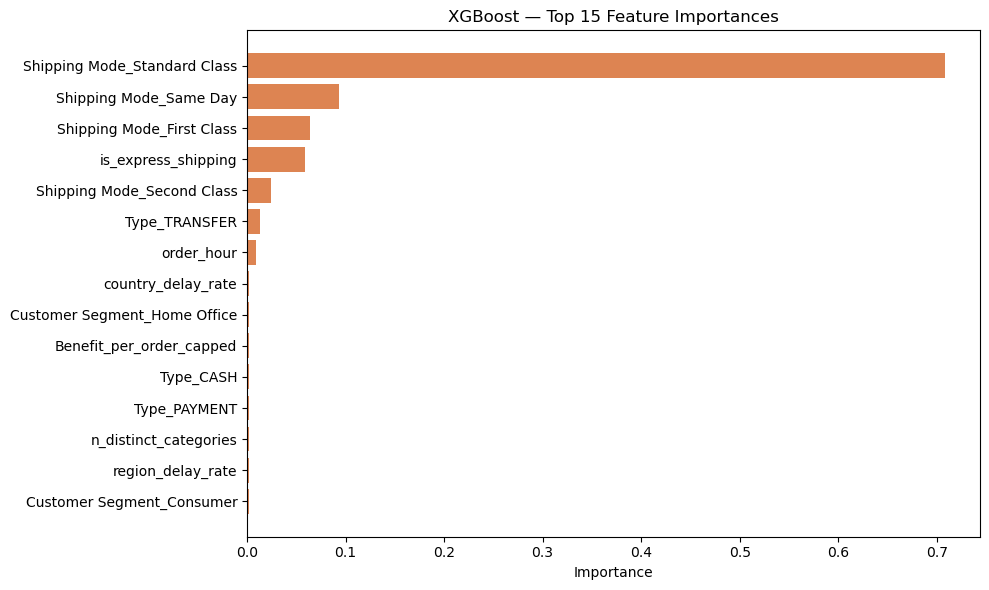

In [5]:
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': xgb.feature_importances_})
importance_df = importance_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='#DD8452')
plt.xlabel('Importance')
plt.title('XGBoost — Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../../../reports/figures/xgb_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


**What we found:**

**Shipping Mode dominates even more heavily here than in either Logistic Regression or Random Forest, over 90% of total importance sits across the Shipping Mode one hot columns and `is_express_shipping` combined, with `Shipping Mode_Standard Class` alone accounting for roughly 70%.** This is broadly consistent with everything found so far, Shipping Mode is clearly the single most important signal across every model tested.

**A genuinely interesting cross model discrepancy: `order_hour` barely registers here (~0.01), in sharp contrast to Random Forest's permutation importance, where it ranked 2nd overall with a confidence interval that didn't cross zero.** Two models are disagreeing meaningfully about how much this one feature matters. A few possible explanations: (1) XGBoost's gain based importance can itself be biased toward features used in a small number of highly impactful early splits, which would systematically favor the already dominant Shipping Mode signal and underweight everything else by comparison, or (2) the two algorithms may genuinely be relying on different features to reach similar overall performance, a known phenomenon in ML sometimes called the "Rashomon effect," where multiple models fit the same data via different, equally valid feature-reliance patterns.

**We shouldn't resolve this from either raw importance chart alone.** Both MDI style and gain based tree importances have known biases, which is exactly why SHAP analysis is already planned for Stage 8, it isn't biased by feature cardinality or split position the way these built in measures are, and it can directly show whether `order_hour` actually matters for XGBoost's predictions or not. Treat the `order_hour` question as genuinely open until then, not settled by either chart individually.


## 4. Save model and metrics

In [8]:
joblib.dump(xgb, '../../../models/xgboost.pkl')
save_metrics(xgb_metrics, '../../../data/processed/metrics_xgb.json')


Saved metrics to ../../../data/processed/metrics_xgb.json
